<a href="https://colab.research.google.com/github/ndourabdourahmaneyoussouf-ops/bird-species-detection-cub200/blob/main/Projet_Oiseaux_Ravageurs_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐦 Détection automatique d'oiseaux ravageurs pour les cultures de riz
## Projet final — Certificat en Intelligence Artificielle

**Concepteur : Alla LO**

Version **réutilisable et orientée ingénierie** du notebook.

### Pipeline
**Données → contrôle qualité → split stratifié → augmentation → CNN baseline → MobileNetV2 Transfer Learning → Fine-Tuning → évaluation → analyse des erreurs → benchmark → Gradio → artefacts reproductibles**

> **Point scientifique important :** le sous-ensemble CUB utilisé dans l'expérience actuelle contient 10 espèces. Il ne permet pas, à lui seul, d'affirmer qu'une espèce est un ravageur du riz dans la vallée du fleuve Sénégal. Le statut « ravageur potentiel » est donc configurable et doit être validé par une annotation experte ou un jeu de données local.

In [2]:
# ============================================================
# 1. ENVIRONNEMENT ET IMPORTATIONS
# ============================================================

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "gradio>=5,<6"
    ])

import os
import json
import random
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import gradio as gr

warnings.filterwarnings("ignore")

print("Python :", platform.python_version())
print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

Python : 3.13.15
TensorFlow : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# 2. CONFIGURATION CENTRALE
# ============================================================

SEED = 42

BASE_DIR = Path("/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEURS")
DATA_DIR = BASE_DIR / "dataset"
MODEL_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "résultats"

CUB_DIR = DATA_DIR / "CUB_200_2011"
IMAGES_DIR = CUB_DIR / "images"
CLASSES_FILE = CUB_DIR / "classes.txt"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
N_CLASSES = 10

EPOCHS_BASELINE = 10
EPOCHS_TRANSFER = 10
EPOCHS_FINETUNE = 10

LR_BASELINE = 1e-3
LR_TRANSFER = 1e-4
LR_FINETUNE = 1e-5

FINE_TUNE_LAYERS = 30
TOP_K = 5

# ============================================================
# IMPORTANT
# ============================================================

# True = entraîner les modèles et créer les historiques
RUN_TRAINING = True

# Comparaison expérimentale supplémentaire
RUN_VALID_COMPARISON = True

RAVAGEUR_CLASSES = set()

for p in [BASE_DIR, DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Projet :", BASE_DIR)
print("Taille image :", IMG_SIZE)
print("Batch :", BATCH_SIZE)
print("RUN_TRAINING :", RUN_TRAINING)

Projet : /content/drive/MyDrive/PROJET_OISEAUX_RAVAGEURS
Taille image : (224, 224)
Batch : 32
RUN_TRAINING : True


In [4]:
# ============================================================
# 3. REPRODUCTIBILITÉ ET GOOGLE DRIVE
# ============================================================

import os
import random
import shutil
import numpy as np
import tensorflow as tf

from google.colab import drive

# ------------------------------------------------------------
# Nettoyage de l'ancien point de montage
# ------------------------------------------------------------

MOUNT_POINT = "/content/drive"

# Si un ancien montage existe, on le démonte
try:
    drive.flush_and_unmount()
    print("Ancien montage Google Drive démonté.")
except Exception:
    pass

# Supprime uniquement le point de montage local /content/drive
# Cela ne supprime PAS les fichiers de ton Google Drive.
if os.path.exists(MOUNT_POINT):
    try:
        shutil.rmtree(MOUNT_POINT)
        print("Ancien point de montage supprimé.")
    except Exception as e:
        print("Impossible de supprimer automatiquement :", e)

# Recrée un dossier vide
os.makedirs(MOUNT_POINT, exist_ok=True)

# ------------------------------------------------------------
# Nouveau montage de Google Drive
# ------------------------------------------------------------

drive.mount(MOUNT_POINT)

print("✅ Google Drive monté avec succès")

# ------------------------------------------------------------
# Reproductibilité
# ------------------------------------------------------------

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Déterminisme TensorFlow
# ------------------------------------------------------------

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# ------------------------------------------------------------
# Vérification
# ------------------------------------------------------------

print("Seed :", SEED)
print("GPU :", tf.config.list_physical_devices("GPU"))

Drive not mounted, so nothing to flush and unmount.
Ancien montage Google Drive démonté.
Ancien point de montage supprimé.
Mounted at /content/drive
✅ Google Drive monté avec succès
Seed : 42
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Dataset CUB-200-2011

Les classes sont maintenant **explicites**. C'est plus robuste que la recherche automatique par mots-clés : une nouvelle exécution ne doit pas modifier silencieusement les classes du modèle.

In [5]:
# ============================================================
# 4. CLASSES ET MANIFEST DES IMAGES
# ============================================================

if not IMAGES_DIR.exists():
    raise FileNotFoundError(f"Dossier introuvable : {IMAGES_DIR}")

if not CLASSES_FILE.exists():
    raise FileNotFoundError(f"Fichier introuvable : {CLASSES_FILE}")

SELECTED_CLASSES = [
    "009.Brewer_Blackbird",
    "010.Red_winged_Blackbird",
    "011.Rusty_Blackbird",
    "012.Yellow_headed_Blackbird",
    "113.Baird_Sparrow",
    "114.Black_throated_Sparrow",
    "115.Brewer_Sparrow",
    "116.Chipping_Sparrow",
    "117.Clay_colored_Sparrow",
    "118.House_Sparrow",
]

if len(SELECTED_CLASSES) != N_CLASSES:
    raise ValueError("N_CLASSES ne correspond pas à SELECTED_CLASSES.")

with open(CLASSES_FILE, encoding="utf-8") as f:
    cub_classes = [
        line.strip().split(" ", 1)[1]
        for line in f if line.strip() and " " in line
    ]

missing = [c for c in SELECTED_CLASSES if c not in cub_classes]
if missing:
    raise ValueError("Classes absentes de CUB : " + ", ".join(missing))

CLASS_NAMES = SELECTED_CLASSES.copy()
CLASS_TO_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}

records = []
for class_name in CLASS_NAMES:
    class_dir = IMAGES_DIR / class_name
    if not class_dir.is_dir():
        raise FileNotFoundError(f"Classe absente : {class_dir}")

    for path in sorted(class_dir.rglob("*")):
        if path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "image_path": str(path),
                "label": CLASS_TO_INDEX[class_name],
                "class_name": class_name
            })

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError("Aucune image trouvée.")

print("Images trouvées :", len(df))
display(df["class_name"].value_counts().sort_index().to_frame("Nombre"))

Images trouvées : 583


,Nombre
class_name,
009.Brewer_Blackbird,59
010.Red_winged_Blackbird,60
011.Rusty_Blackbird,60
012.Yellow_headed_Blackbird,56
113.Baird_Sparrow,50
114.Black_throated_Sparrow,60
115.Brewer_Sparrow,59
116.Chipping_Sparrow,60
117.Clay_colored_Sparrow,59


Images invalides : 0
Images valides   : 583


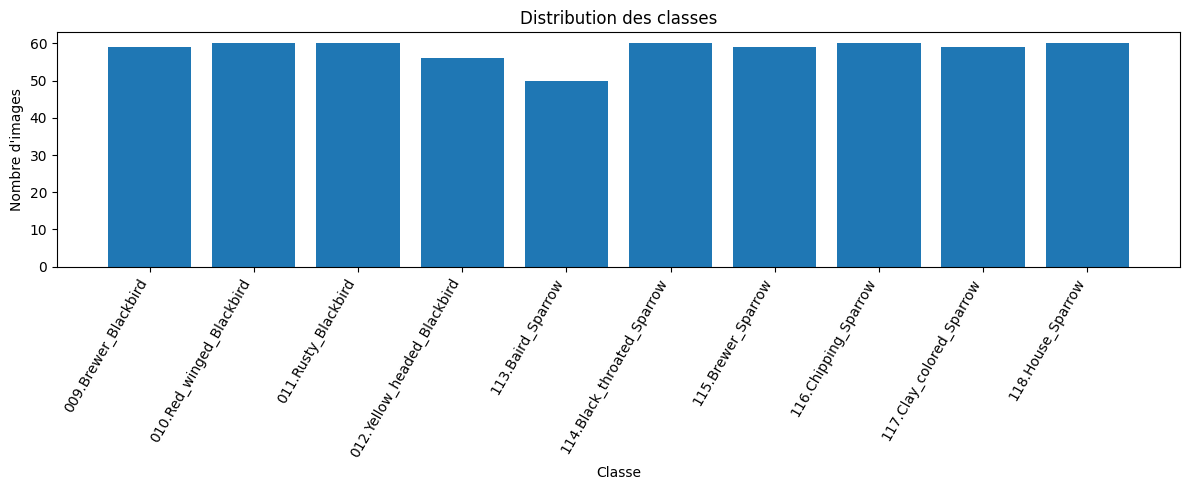

In [6]:
# ============================================================
# 5. CONTRÔLE QUALITÉ DES IMAGES
# ============================================================

def validate_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

valid = df["image_path"].map(validate_image)
invalid_df = df.loc[~valid].copy()
df = df.loc[valid].reset_index(drop=True)

print("Images invalides :", len(invalid_df))
print("Images valides   :", len(df))

if not invalid_df.empty:
    invalid_df.to_csv(RESULTS_DIR / "images_invalides.csv", index=False)

distribution = df["class_name"].value_counts().reindex(CLASS_NAMES)

plt.figure(figsize=(12, 5))
plt.bar(distribution.index, distribution.values)
plt.xticks(rotation=60, ha="right")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "distribution_classes.png", dpi=200)
plt.show()

In [7]:
# ============================================================
# 6. SPLIT STRATIFIÉ TRAIN / VALIDATION / TEST
# ============================================================

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_df = pd.DataFrame({
    "Ensemble": ["Train", "Validation", "Test"],
    "Nombre": [len(train_df), len(val_df), len(test_df)],
    "Proportion": [
        len(train_df)/len(df), len(val_df)/len(df), len(test_df)/len(df)
    ]
})

display(split_df.style.format({"Proportion": "{:.1%}"}))
split_df.to_csv(RESULTS_DIR / "repartition_dataset.csv", index=False)

,Ensemble,Nombre,Proportion
0,Train,408,70.0%
1,Validation,87,14.9%
2,Test,88,15.1%


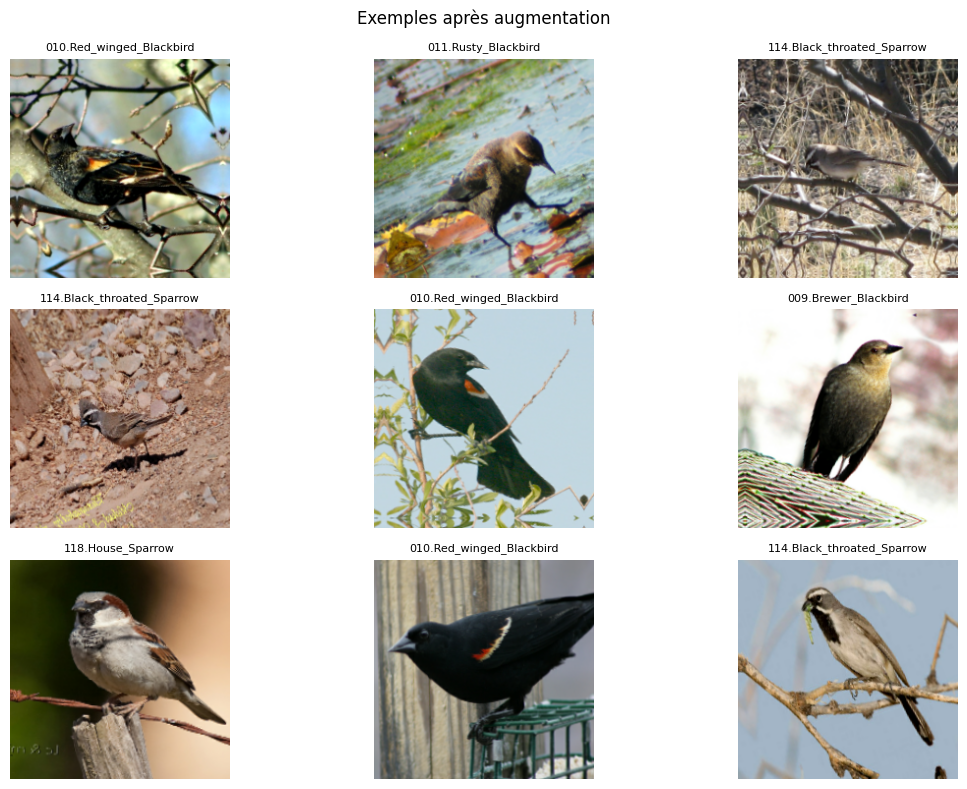

In [8]:
# ============================================================
# 7. PIPELINE TF.DATA + AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")


def load_image(path, label):
    """Charge JPEG/PNG, redimensionne et convertit en float32."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image, channels=3, expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    return tf.cast(image, tf.float32), label


def create_dataset(dataframe, training=False):
    paths = dataframe["image_path"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            len(dataframe), seed=SEED, reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = create_dataset(train_df, True)
val_ds = create_dataset(val_df, False)
test_ds = create_dataset(test_df, False)

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8))
    plt.title(CLASS_NAMES[int(labels[i])], fontsize=8)
    plt.axis("off")
plt.suptitle("Exemples après augmentation")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exemples_augmentation.png", dpi=200)
plt.show()

In [9]:
# ============================================================
# 8. MODÈLES ET ENTRAÎNEMENT
# ============================================================

def build_baseline_model():
    return keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1/255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(N_CLASSES, activation="softmax")
    ], name="CNN_Baseline")


def build_mobilenet_model():
    base = keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="MobileNetV2"), base


def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


def callbacks_for(path):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3,
            patience=1, min_lr=1e-7, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            str(path), monitor="val_loss",
            save_best_only=True, verbose=1
        )
    ]


def train_model(model, epochs, checkpoint):
    start = time.perf_counter()
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=epochs,
        callbacks=callbacks_for(checkpoint), verbose=1
    )
    return history, time.perf_counter() - start

In [10]:
# ============================================================
# 9. ENTRAÎNEMENT OU RECHARGEMENT
# ============================================================

FINAL_MODEL_PATH = MODEL_DIR / "modele_oiseaux_final.keras"
LEGACY_MODEL_PATH = MODEL_DIR / "modele_oiseaux_mobilenetv2_final.keras"
BEST_MODEL_PATH = MODEL_DIR / "meilleur_modele_oiseaux.keras"
CLASS_NAMES_PATH = MODEL_DIR / "classes.json"

history_baseline = history_transfer = history_finetune = None
time_baseline = time_transfer = time_finetune = None
baseline_model = transfer_model = base_model = None

if RUN_TRAINING:
    print("=== CNN BASELINE ===")
    baseline_model = build_baseline_model()
    compile_model(baseline_model, LR_BASELINE)
    history_baseline, time_baseline = train_model(
        baseline_model, EPOCHS_BASELINE,
        MODEL_DIR / "checkpoint_baseline.keras"
    )

    print("=== MOBILENETV2 TRANSFER LEARNING ===")
    transfer_model, base_model = build_mobilenet_model()
    compile_model(transfer_model, LR_TRANSFER)
    history_transfer, time_transfer = train_model(
        transfer_model, EPOCHS_TRANSFER,
        MODEL_DIR / "checkpoint_transfer.keras"
    )

    print("=== MOBILENETV2 FINE-TUNING ===")
    base_model.trainable = True
    for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    compile_model(transfer_model, LR_FINETUNE)
    history_finetune, time_finetune = train_model(
        transfer_model, EPOCHS_FINETUNE, BEST_MODEL_PATH
    )

    final_model = keras.models.load_model(
        BEST_MODEL_PATH if BEST_MODEL_PATH.exists() else FINAL_MODEL_PATH
    )
    final_model.save(FINAL_MODEL_PATH)

else:
    # Compatibilité avec le nom utilisé dans l'ancien notebook.
    model_to_load = (
        FINAL_MODEL_PATH
        if FINAL_MODEL_PATH.exists()
        else LEGACY_MODEL_PATH
    )

    if not model_to_load.exists():
        raise FileNotFoundError(
            f"Aucun modèle final trouvé.\n"
            f"Recherchés : {FINAL_MODEL_PATH} et {LEGACY_MODEL_PATH}\n"
            "Pour une première exécution, mettre RUN_TRAINING=True."
        )

    final_model = keras.models.load_model(model_to_load)
    print("Modèle chargé :", model_to_load)

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

print("Modèle final :", FINAL_MODEL_PATH)

=== CNN BASELINE ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.1196 - loss: 2.4810
Epoch 1: val_loss improved from None to 2.29230, saving model to /content/drive/MyDrive/PROJET_OISEAUX_RAVAGEURS/models/checkpoint_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PROJET_OISEAUX_RAVAGEURS/models/checkpoint_baseline.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 969ms/step - accuracy: 0.1324 - loss: 2.4558 - val_accuracy: 0.1149 - val_loss: 2.2923 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.1700 - loss: 2.3286
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 2: val_loss did not improve from 2.29230
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 726ms/step - accuracy: 0.1961 - loss: 2.3063 - val_accuracy: 0.0920 - val_loss: 2.2966 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.2344 - loss: 2.1457
Epoch 3: ReduceLROnPlateau reducing learning rate to

## 10. Courbes d'apprentissage

Les courbes sont produites uniquement lorsqu'un entraînement est exécuté dans la session. Cela évite d'associer par erreur une courbe à un autre modèle.

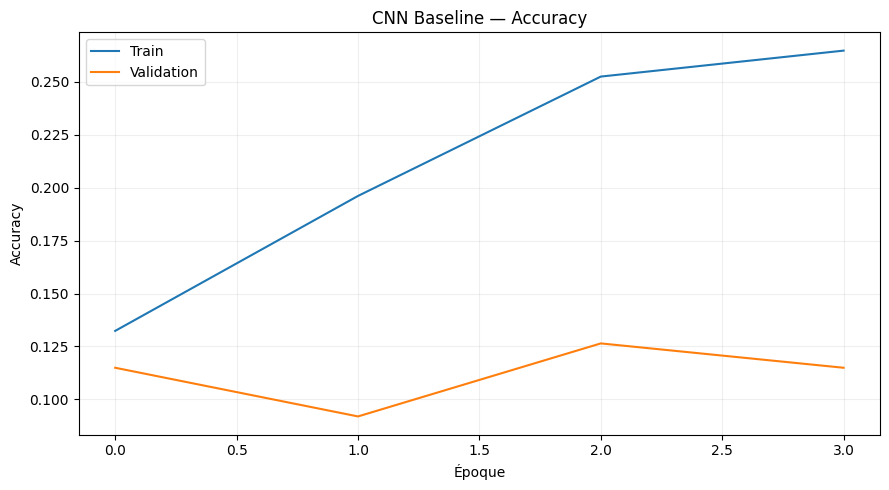

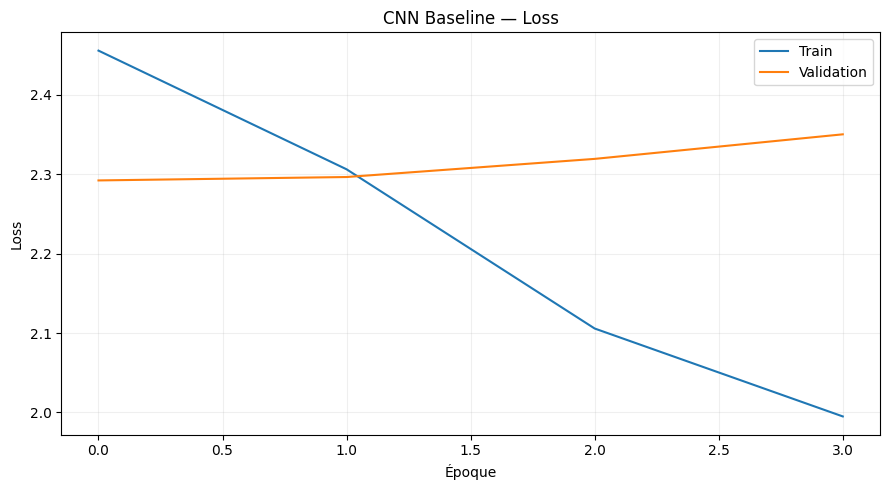

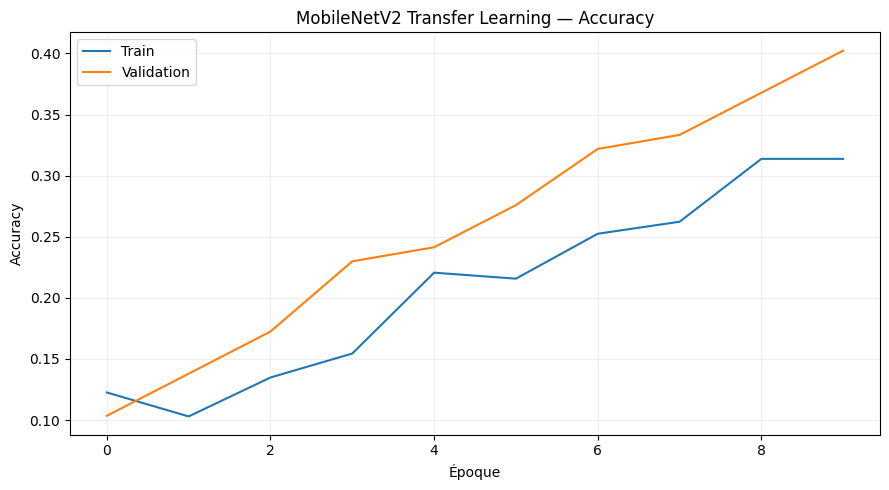

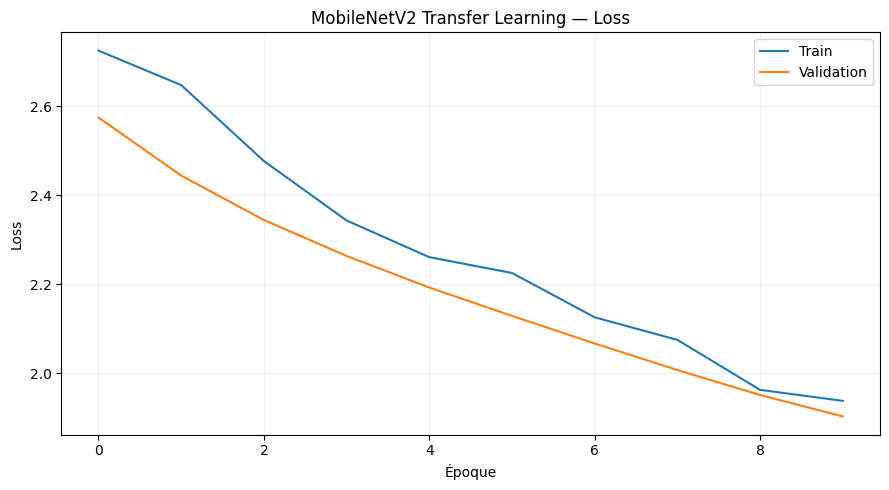

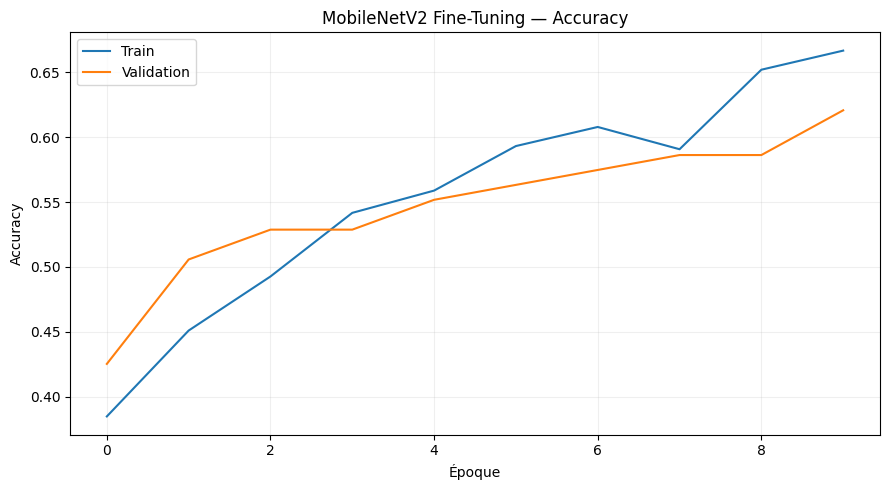

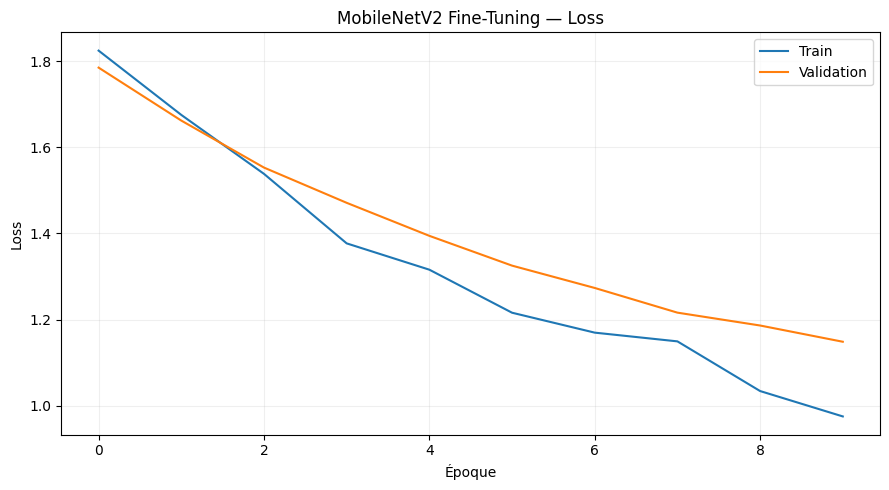

In [11]:
# ============================================================
# 10. COURBES ACCURACY / LOSS
# ============================================================

def plot_history(history, title, prefix):
    if history is None:
        print(f"Historique indisponible : {title}")
        return

    h = history.history

    plt.figure(figsize=(9, 5))
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("Accuracy")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{prefix}_accuracy.png", dpi=200)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{prefix}_loss.png", dpi=200)
    plt.show()


plot_history(history_baseline, "CNN Baseline", "cnn_baseline")
plot_history(history_transfer, "MobileNetV2 Transfer Learning", "mobilenet_transfer")
plot_history(history_finetune, "MobileNetV2 Fine-Tuning", "mobilenet_finetuning")

In [12]:
# ============================================================
# 11. ÉVALUATION FINALE
# ============================================================

def predict_dataset(model, dataset):
    y_true, y_pred, y_prob = [], [], []

    for images, labels in dataset:
        prob = model.predict(images, verbose=0)
        pred = np.argmax(prob, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred)
        y_prob.extend(prob)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "Recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "F1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "Precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "F1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        )
    }


y_true, y_pred, y_prob = predict_dataset(final_model, test_ds)
final_metrics = compute_metrics(y_true, y_pred)

print("=== PERFORMANCE FINALE ===")
for k, v in final_metrics.items():
    print(f"{k:22s}: {v:.4f}")

report_df = pd.DataFrame(
    classification_report(
        y_true, y_pred, target_names=CLASS_NAMES,
        zero_division=0, output_dict=True
    )
).T

display(report_df.style.format({
    "precision": "{:.2%}",
    "recall": "{:.2%}",
    "f1-score": "{:.2%}"
}))

report_df.to_csv(RESULTS_DIR / "classification_report.csv")

=== PERFORMANCE FINALE ===
Accuracy              : 0.6477
Precision_weighted    : 0.6466
Recall_weighted       : 0.6477
F1_weighted           : 0.6379
Precision_macro       : 0.6512
Recall_macro          : 0.6524
F1_macro              : 0.6428


,precision,recall,f1-score,support
009.Brewer_Blackbird,55.56%,55.56%,55.56%,9.000000
010.Red_winged_Blackbird,69.23%,100.00%,81.82%,9.000000
011.Rusty_Blackbird,62.50%,55.56%,58.82%,9.000000
012.Yellow_headed_Blackbird,100.00%,88.89%,94.12%,9.000000
113.Baird_Sparrow,85.71%,85.71%,85.71%,7.000000
114.Black_throated_Sparrow,81.82%,100.00%,90.00%,9.000000
115.Brewer_Sparrow,83.33%,55.56%,66.67%,9.000000
116.Chipping_Sparrow,28.57%,22.22%,25.00%,9.000000
117.Clay_colored_Sparrow,42.86%,33.33%,37.50%,9.000000
118.House_Sparrow,41.67%,55.56%,47.62%,9.000000


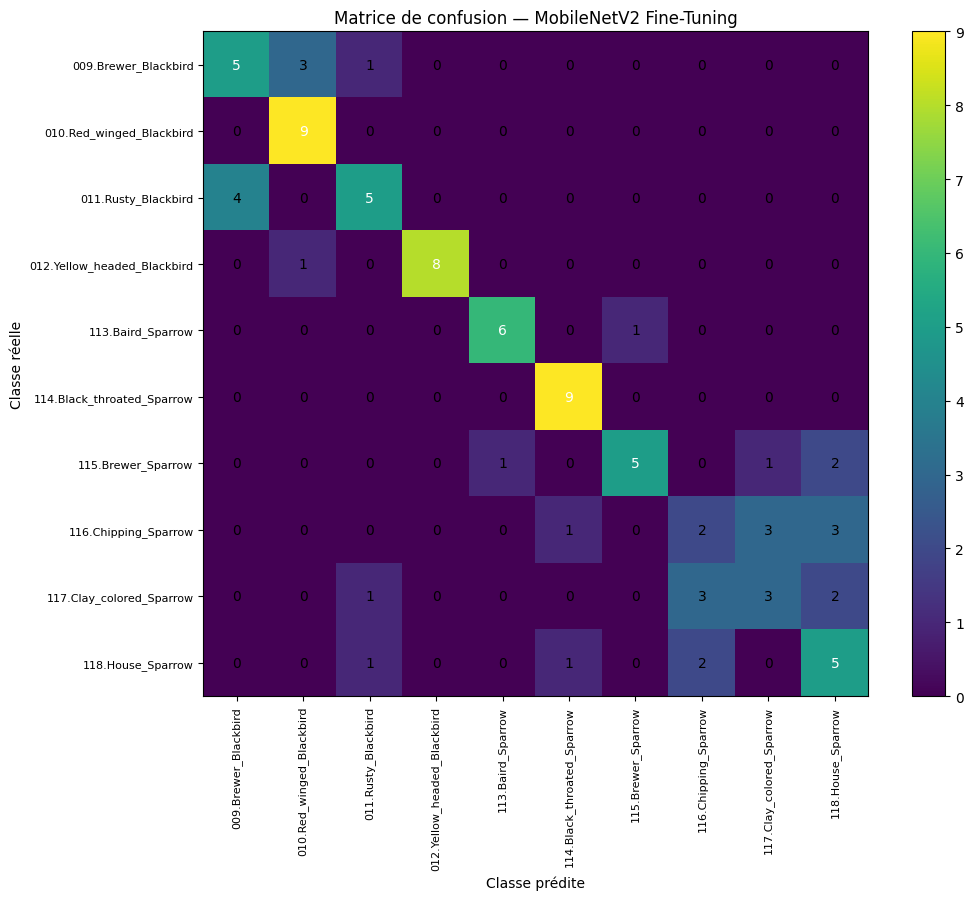

Images testées : 88
Erreurs : 31
Confiance moyenne : 52.83%
Confiance moyenne des erreurs : 39.36%


,Classe,Support,Correctes,Incorrectes,Recall_classe,Taux_erreur
7,116.Chipping_Sparrow,9,2,7,22.22%,77.78%
8,117.Clay_colored_Sparrow,9,3,6,33.33%,66.67%
6,115.Brewer_Sparrow,9,5,4,55.56%,44.44%
0,009.Brewer_Blackbird,9,5,4,55.56%,44.44%
9,118.House_Sparrow,9,5,4,55.56%,44.44%
2,011.Rusty_Blackbird,9,5,4,55.56%,44.44%
4,113.Baird_Sparrow,7,6,1,85.71%,14.29%
3,012.Yellow_headed_Blackbird,9,8,1,88.89%,11.11%
5,114.Black_throated_Sparrow,9,9,0,100.00%,0.00%
1,010.Red_winged_Blackbird,9,9,0,100.00%,0.00%


In [13]:
# ============================================================
# 12. MATRICE DE CONFUSION + ANALYSE DES ERREURS
# ============================================================

cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))

plt.figure(figsize=(11, 9))
plt.imshow(cm, interpolation="nearest")
plt.title("Matrice de confusion — MobileNetV2 Fine-Tuning")
plt.colorbar()
plt.xticks(np.arange(N_CLASSES), CLASS_NAMES, rotation=90, fontsize=8)
plt.yticks(np.arange(N_CLASSES), CLASS_NAMES, fontsize=8)

threshold = cm.max() / 2 if cm.size else 0
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        plt.text(
            j, i, str(cm[i, j]), ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "matrice_confusion.png", dpi=250)
plt.show()

pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    RESULTS_DIR / "matrice_confusion.csv"
)

confidence = np.max(y_prob, axis=1)
error_df = test_df.copy()
error_df["true_class"] = [CLASS_NAMES[i] for i in y_true]
error_df["pred_class"] = [CLASS_NAMES[i] for i in y_pred]
error_df["confidence"] = confidence
error_df["correct"] = y_true == y_pred

print("Images testées :", len(error_df))
print("Erreurs :", int((~error_df["correct"]).sum()))
print("Confiance moyenne :", f"{confidence.mean():.2%}")

if (~error_df["correct"]).any():
    print(
        "Confiance moyenne des erreurs :",
        f"{confidence[~error_df['correct']].mean():.2%}"
    )

error_df.to_csv(
    RESULTS_DIR / "predictions_test_completes.csv", index=False
)

per_class = []
for i, name in enumerate(CLASS_NAMES):
    mask = y_true == i
    n = int(mask.sum())
    if n:
        correct = int((y_pred[mask] == i).sum())
        per_class.append({
            "Classe": name,
            "Support": n,
            "Correctes": correct,
            "Incorrectes": n - correct,
            "Recall_classe": correct / n,
            "Taux_erreur": (n - correct) / n
        })

per_class_df = pd.DataFrame(per_class).sort_values("Recall_classe")
display(per_class_df.style.format({
    "Recall_classe": "{:.2%}",
    "Taux_erreur": "{:.2%}"
}))
per_class_df.to_csv(
    RESULTS_DIR / "performance_par_classe.csv", index=False
)

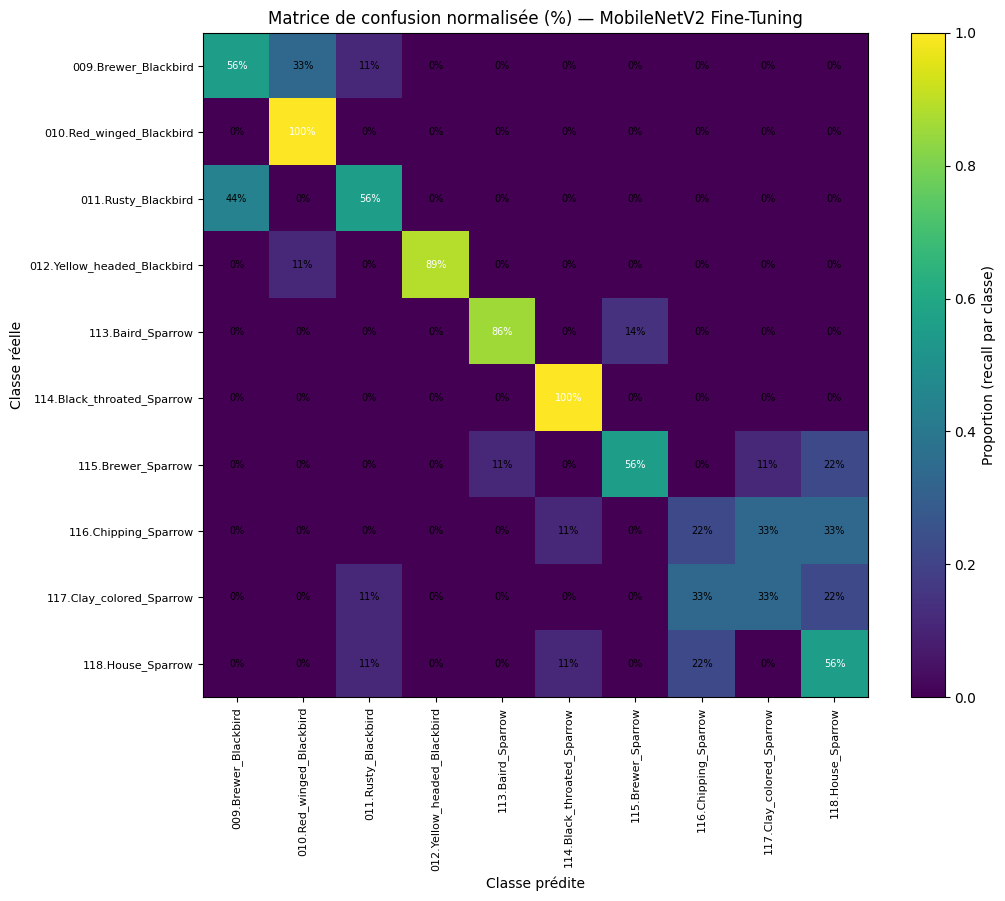

In [14]:
# ============================================================
# 12bis. MATRICE DE CONFUSION NORMALISÉE (HEATMAP EN %)
# ============================================================
# Complète la matrice brute ci-dessus : ici chaque ligne (classe réelle)
# est normalisée à 100%, ce qui rend le recall par classe directement
# lisible sur la heatmap, indépendamment du nombre d'images par classe.

cm_norm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES), normalize="true")

plt.figure(figsize=(11, 9))
plt.imshow(cm_norm, interpolation="nearest", cmap="viridis", vmin=0, vmax=1)
plt.title("Matrice de confusion normalisée (%) — MobileNetV2 Fine-Tuning")
plt.colorbar(label="Proportion (recall par classe)")
plt.xticks(np.arange(N_CLASSES), CLASS_NAMES, rotation=90, fontsize=8)
plt.yticks(np.arange(N_CLASSES), CLASS_NAMES, fontsize=8)

threshold = cm_norm.max() / 2 if cm_norm.size else 0
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        plt.text(
            j, i, f"{cm_norm[i, j]:.0%}", ha="center", va="center",
            color="white" if cm_norm[i, j] > threshold else "black", fontsize=7
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "matrice_confusion_normalisee.png", dpi=250)
plt.show()

pd.DataFrame(cm_norm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    RESULTS_DIR / "matrice_confusion_normalisee.csv"
)


In [15]:
# ============================================================
# 13. FAUX NÉGATIFS RAVAGEURS
# ============================================================
# Le cahier des charges donne la priorité au recall ravageur.
# On ne déduit PAS le statut ravageur du nom de l'espèce.

def analyze_pest_errors(y_true, y_pred, class_names, pest_classes):
    pest_classes = set(pest_classes)

    if not pest_classes:
        print(
            "⚠️ RAVAGEUR_CLASSES est vide : analyse binaire non calculée.\n"
            "Renseigner cette variable uniquement avec une annotation "
            "agronomique validée."
        )
        return None

    unknown = pest_classes - set(class_names)
    if unknown:
        raise ValueError("Classes inconnues : " + ", ".join(unknown))

    true_bin = np.array(
        [class_names[i] in pest_classes for i in y_true], dtype=int
    )
    pred_bin = np.array(
        [class_names[i] in pest_classes for i in y_pred], dtype=int
    )

    tn, fp, fn, tp = confusion_matrix(
        true_bin, pred_bin, labels=[0, 1]
    ).ravel()

    result = {
        "TN": int(tn), "FP": int(fp),
        "FN": int(fn), "TP": int(tp),
        "Precision_ravageur": precision_score(
            true_bin, pred_bin, zero_division=0
        ),
        "Recall_ravageur": recall_score(
            true_bin, pred_bin, zero_division=0
        ),
        "F1_ravageur": f1_score(
            true_bin, pred_bin, zero_division=0
        )
    }

    result["Taux_faux_negatifs"] = (
        fn / (fn + tp) if fn + tp else 0.0
    )

    display(pd.DataFrame([result]).style.format({
        "Precision_ravageur": "{:.2%}",
        "Recall_ravageur": "{:.2%}",
        "F1_ravageur": "{:.2%}",
        "Taux_faux_negatifs": "{:.2%}"
    }))

    pd.DataFrame([result]).to_csv(
        RESULTS_DIR / "metriques_ravageur.csv", index=False
    )
    return result

pest_metrics = analyze_pest_errors(
    y_true, y_pred, CLASS_NAMES, RAVAGEUR_CLASSES
)

⚠️ RAVAGEUR_CLASSES est vide : analyse binaire non calculée.
Renseigner cette variable uniquement avec une annotation agronomique validée.


Vraie classe : 012.Yellow_headed_Blackbird
Classe prédite : 012.Yellow_headed_Blackbird
Confiance : 33.31%
Statut : ⚠️ STATUT RAVAGEUR NON CONFIGURÉ


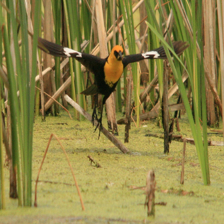

,classe,probabilité
0,012.Yellow_headed_Blackbird,33.31%
1,010.Red_winged_Blackbird,25.86%
2,009.Brewer_Blackbird,21.84%
3,011.Rusty_Blackbird,11.80%
4,113.Baird_Sparrow,2.04%


In [16]:
# ============================================================
# 14. PRÉDICTION RÉUTILISABLE + TEST DATASET
# ============================================================

def preprocess_image(image):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))
    if not isinstance(image, Image.Image):
        raise TypeError("L'entrée doit être une image PIL ou NumPy.")
    image = image.convert("RGB").resize(IMG_SIZE)
    return image, np.asarray(image, dtype=np.float32)


def predict_image(image, model=final_model, top_k=TOP_K):
    pil, array = preprocess_image(image)
    probabilities = model.predict(
        np.expand_dims(array, 0), verbose=0
    )[0]

    indices = np.argsort(probabilities)[-top_k:][::-1]

    top = [
        {
            "classe": CLASS_NAMES[int(i)],
            "probabilité": float(probabilities[i])
        }
        for i in indices
    ]

    idx = int(indices[0])
    predicted_class = CLASS_NAMES[idx]
    confidence = float(probabilities[idx])

    if RAVAGEUR_CLASSES:
        status = (
            "🚨 RAVAGEUR POTENTIEL"
            if predicted_class in RAVAGEUR_CLASSES
            else "ℹ️ OISEAU NON PRIORITAIRE"
        )
    else:
        status = "⚠️ STATUT RAVAGEUR NON CONFIGURÉ"

    return {
        "image": pil,
        "classe": predicted_class,
        "confiance": confidence,
        "top": top,
        "statut": status
    }


row = test_df.iloc[0]
result = predict_image(Image.open(row["image_path"]))

print("Vraie classe :", row["class_name"])
print("Classe prédite :", result["classe"])
print("Confiance :", f"{result['confiance']:.2%}")
print("Statut :", result["statut"])
display(result["image"])
display(pd.DataFrame(result["top"]).style.format({
    "probabilité": "{:.2%}"
}))

In [17]:
# ============================================================
# 15. BENCHMARK D'INFÉRENCE
# ============================================================

def benchmark_inference(model, dataframe, n_images=30):
    n = min(n_images, len(dataframe))
    sample = dataframe.sample(n=n, random_state=SEED)

    batch = np.stack([
        np.asarray(
            Image.open(p).convert("RGB").resize(IMG_SIZE),
            dtype=np.float32
        )
        for p in sample["image_path"]
    ])

    # Warm-up
    model.predict(batch[:1], verbose=0)

    start = time.perf_counter()
    model.predict(batch, verbose=0)
    elapsed = time.perf_counter() - start

    result = {
        "Images testées": n,
        "Temps total (s)": elapsed,
        "Temps moyen (ms/image)": elapsed / n * 1000,
        "Images/seconde": n / elapsed if elapsed else np.nan
    }

    display(pd.DataFrame([result]).style.format({
        "Temps total (s)": "{:.3f}",
        "Temps moyen (ms/image)": "{:.2f}",
        "Images/seconde": "{:.2f}"
    }))

    pd.DataFrame([result]).to_csv(
        RESULTS_DIR / "temps_inference.csv", index=False
    )
    return result

inference_result = benchmark_inference(final_model, test_df, 30)

,Images testées,Temps total (s),Temps moyen (ms/image),Images/seconde
0,30,0.227,7.56,132.26


## 16. Comparaison des modèles — correction méthodologique

Dans l'ancien notebook, après le Fine-Tuning, `transfer_model` était modifié puis réutilisé dans le tableau final. Il était donc incorrect de présenter ensuite cet objet comme un modèle « Transfer Learning » distinct.

La comparaison ci-dessous réentraîne les modèles lorsque `RUN_VALID_COMPARISON=True`. Elle permet une comparaison propre sur **le même split de test**.

In [18]:
# ============================================================
# 16. COMPARAISON EXPÉRIMENTALE OPTIONNELLE
# ============================================================

comparison_rows = []

if RUN_VALID_COMPARISON:
    cnn = build_baseline_model()
    compile_model(cnn, LR_BASELINE)
    h_cnn, t_cnn = train_model(
        cnn, EPOCHS_BASELINE, MODEL_DIR / "comparison_cnn.keras"
    )
    yt, yp, _ = predict_dataset(cnn, test_ds)
    comparison_rows.append({
        "Modèle": "CNN Baseline",
        **compute_metrics(yt, yp),
        "Temps entraînement (min)": t_cnn / 60
    })

    tl, _ = build_mobilenet_model()
    compile_model(tl, LR_TRANSFER)
    h_tl, t_tl = train_model(
        tl, EPOCHS_TRANSFER, MODEL_DIR / "comparison_transfer.keras"
    )
    yt, yp, _ = predict_dataset(tl, test_ds)
    comparison_rows.append({
        "Modèle": "MobileNetV2 Transfer Learning",
        **compute_metrics(yt, yp),
        "Temps entraînement (min)": t_tl / 60
    })

    comparison_rows.append({
        "Modèle": "MobileNetV2 Fine-Tuning",
        **final_metrics,
        "Temps entraînement (min)":
            time_finetune / 60 if time_finetune else np.nan
    })

    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision_weighted": "{:.2%}",
        "Recall_weighted": "{:.2%}",
        "F1_weighted": "{:.2%}",
        "Precision_macro": "{:.2%}",
        "Recall_macro": "{:.2%}",
        "F1_macro": "{:.2%}",
        "Temps entraînement (min)": "{:.2f}"
    }))
    comparison_df.to_csv(
        RESULTS_DIR / "comparaison_modeles_valide.csv", index=False
    )
else:
    print(
        "Comparaison complète désactivée. "
        "Activer RUN_VALID_COMPARISON=True pour la recalculer."
    )

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.1342 - loss: 2.4617
Epoch 1: val_loss improved from None to 2.29926, saving model to /content/drive/MyDrive/PROJET_OISEAUX_RAVAGEURS/models/comparison_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PROJET_OISEAUX_RAVAGEURS/models/comparison_cnn.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 834ms/step - accuracy: 0.1446 - loss: 2.4416 - val_accuracy: 0.0920 - val_loss: 2.2993 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.2298 - loss: 2.1833
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 2: val_loss did not improve from 2.29926
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 632ms/step - accuracy: 0.2108 - loss: 2.2487 - val_accuracy: 0.0920 - val_loss: 2.2994 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.2880 - loss: 2.0487
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 

,Modèle,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Temps entraînement (min)
0,CNN Baseline,9.09%,1.22%,9.09%,2.15%,1.19%,8.89%,2.11%,0.67
1,MobileNetV2 Transfer Learning,43.18%,44.62%,43.18%,41.18%,45.11%,44.13%,41.93%,1.66
2,MobileNetV2 Fine-Tuning,64.77%,64.66%,64.77%,63.79%,65.12%,65.24%,64.28%,1.77


## 17. Démonstration Gradio

L'interface utilise la **même fonction de prétraitement** que les tests du notebook. Cela évite qu'un prétraitement différent entre le notebook et l'application dégrade les prédictions.

In [19]:
# ============================================================
# 17. INTERFACE GRADIO
# ============================================================

def prediction_gradio(image):
    if image is None:
        return "⚠️ Veuillez charger une image.", None, {}

    try:
        result = predict_image(image)

        classe = result["classe"]
        confiance = result["confiance"]

        # ----------------------------------------------------
        # INTERPRÉTATION DE LA CONFIANCE
        # ----------------------------------------------------

        if confiance >= 0.70:
            niveau = "🟢 Confiance élevée"
            interpretation = (
                "La prédiction est considérée comme relativement fiable."
            )

        elif confiance >= 0.50:
            niveau = "🟠 Confiance modérée"
            interpretation = (
                "L'espèce est probablement identifiée, "
                "mais une vérification humaine reste recommandée."
            )

        else:
            niveau = "🔴 Confiance faible"
            interpretation = (
                "La prédiction est incertaine. "
                "Une vérification humaine est fortement recommandée."
            )

        # ----------------------------------------------------
        # MESSAGE AFFICHÉ DANS L'INTERFACE
        # ----------------------------------------------------

        message = (
            f"🐦 Classe prédite : {classe}\n"
            f"📊 Confiance : {confiance:.2%}\n"
            f"{niveau}\n\n"
            f"{interpretation}"
        )

        # Top-5 prédictions
        top = {
            x["classe"]: x["probabilité"]
            for x in result["top"]
        }

        return message, result["image"], top

    except Exception as exc:
        return f"❌ Erreur : {exc}", None, {}


demo = gr.Interface(
    fn=prediction_gradio,
    inputs=gr.Image(
        type="numpy",
        label="Image d'oiseau"
    ),
    outputs=[
        gr.Textbox(
            label="Résultat",
            lines=6
        ),
        gr.Image(
            label="Image analysée"
        ),
        gr.Label(
            label="Top-5 prédictions",
            num_top_classes=5
        )
    ],
    title="🐦 Détection automatique d'oiseaux",
    description=(
        "Prototype de classification d'oiseaux basé sur "
        "MobileNetV2, Transfer Learning et Fine-Tuning."
    ),
    flagging_mode="never"
)

print("Interface prête.")

# Lancement de l'interface
demo.launch(share=True)

Interface prête.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63121fdd91c4d16ae0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [20]:
# ============================================================
# 18. SAUVEGARDE DES ARTEFACTS ET SYNTHÈSE
# ============================================================

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

config = {
    "projet": "Détection automatique d'oiseaux ravageurs",
    "concepteur": "Alla LO",
    "dataset": "CUB-200-2011",
    "classes": CLASS_NAMES,
    "image_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "fine_tune_layers": FINE_TUNE_LAYERS,
    "ravageur_classes": sorted(RAVAGEUR_CLASSES),
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "gpu": [d.name for d in tf.config.list_physical_devices("GPU")],
    "metrics_final": final_metrics,
    "inference": inference_result
}

with open(MODEL_DIR / "project_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

summary = {
    "Projet": "Détection automatique d'oiseaux ravageurs",
    "Concepteur": "Alla LO",
    "Dataset": "CUB-200-2011",
    "Classes": len(CLASS_NAMES),
    "Images": len(df),
    "Train": len(train_df),
    "Validation": len(val_df),
    "Test": len(test_df),
    **final_metrics,
    **inference_result
}

pd.DataFrame([summary]).to_csv(
    RESULTS_DIR / "synthese_finale.csv", index=False
)

final_model.save(FINAL_MODEL_PATH)

required = [
    FINAL_MODEL_PATH,
    CLASS_NAMES_PATH,
    MODEL_DIR / "project_config.json",
    RESULTS_DIR / "classification_report.csv",
    RESULTS_DIR / "matrice_confusion.csv",
    RESULTS_DIR / "predictions_test_completes.csv",
    RESULTS_DIR / "performance_par_classe.csv",
    RESULTS_DIR / "temps_inference.csv",
    RESULTS_DIR / "synthese_finale.csv"
]

status = pd.DataFrame({
    "Artefact": [str(p) for p in required],
    "Présent": [p.exists() for p in required]
})

display(status)

if status["Présent"].all():
    print("✅ Pipeline et artefacts essentiels prêts.")
else:
    print("⚠️ Certains artefacts manquent : vérifier les cellules précédentes.")

,Artefact,Présent
0,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
1,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
2,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
3,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
4,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
5,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
6,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
7,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True
8,/content/drive/MyDrive/PROJET_OISEAUX_RAVAGEUR...,True


✅ Pipeline et artefacts essentiels prêts.
